# Injected thoughts and verbal introspection — Qwen3-4B, pre-fitted lens

Add a concept's J-lens direction to the residual stream while the model is asked whether a
thought has been injected into it, and see whether the model names that concept. This is the
paper's injection/introspection protocol on the committed prompt set
(`data/experiments/verbal-introspection.json`: the researcher framing, a teacher-forced
reply ending in an open quote, and 101 concepts), with the lens downloaded from
`neuronpedia/jacobian-lens` — nothing is fitted here.

**Answer (this run, §4).** **No — this claim does not reproduce on Qwen3-4B**, and the
contrast arm shows why the obvious positive result is an artifact. Injected over the
protocol's span (the user's question turn), no strength and no band ever gets the concept
reported: at most 1.4% of trials name it, indistinguishable from random directions, and the
model answers `"thought."` in essentially every trial — it is completing the prefill's
sentence pattern, not introspecting. Injected over the *whole* prompt, 100% of trials
"name" the concept at every strength — but that number is worthless: the greedy
continuations are `"lightlightlightlight..."`, `"oooooooooo"` and `"cincincincin..."`, and
logit-lens directions achieve the same 100%. That arm includes the readout position itself,
so it is adding a token's unembedding direction to the very residual that is then
unembedded, which raises that token's logit by construction. It is output steering, not
verbal report. The control behaves correctly throughout (0% named at strength 0, median
rank 1790), so the experiment is well-posed; Qwen3-4B simply does not do this task. The
paper's figures come from Haiku, Sonnet and Opus.

## Method

**Prompt** (`data/experiments/README.md`, verbal-introspection). The model is told that an
interpretability researcher can inject concepts into its activations, that half of trials
are controls, and that its job is to detect and identify any injected thought. One of
`prefills` is teacher-forced as its reply, ending in an open quote, so the next predicted
token is the reported word. Everything is read at that quote.

**Injection.** For concept token `t`, the steering vector is the unit-normalized lens
direction `v_t = J_l^T (gamma * u_t)` scaled by the layer's mean residual norm over the
patched positions, times a `strength` scalar, added at every band layer across the tokens of
the user's question turn (`jlens.workspace.InjectDirection`). Scaling by the layer's own
norm keeps one `strength` comparable across layers of very different scale. Qwen3 uses
RMSNorm, so `v_t` carries no centering term — see `concept_swap.ipynb` §Method.

**Score.** The rank of the concept's surface form in the next-token distribution at the open
quote. **`strength = 0` is the control trial**, which is what makes this a detection
experiment rather than a steering demo: the model must not name the concept when nothing was
injected. Reported as median reciprocal rank against strength, plus the fraction of trials
where the concept is named outright.

**Controls.** `logit` directions (the same construction with `J_l = I`) and `random`
directions of the same norm. A random vector of this size pushed into mid-network
activations will derail the model; the question is whether it makes the model name *that
concept*.

**No correctness filter.** The other notebooks in this directory keep only the questions
the model answers correctly before reading anything off them. Here there is no such question
to pre-check: the right answer of an injected trial is the injected concept itself, which is
the outcome being measured, and the right answer of a control trial (strength 0) is *not*
naming it — which holds in all 2220 control trials (§3). Every trial is therefore kept.

**Not covered.** The paper also reports an A/B-choice arm, where J-space contents are
swapped between a "happy" and a "sad" framing. That prompt set is not in
`data/experiments/`, so it is out of scope here.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# Opened from a clone (notebooks/<lens>/): use the repository root above the notebook.
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "workspace.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

In [2]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

import jlens
from jlens.workspace import InjectDirection, final_norm_centers

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 240)

In [3]:
MODEL_ID = os.environ.get("JLENS_MODEL_ID", "Qwen/Qwen3-4B")
LENS_REPO = "neuronpedia/jacobian-lens"
LENS_FILE = {  # lenses fitted by this library's fit_lens.py on 1000 WikiText-103 x 128 tokens
    "Qwen/Qwen3-4B": "qwen3-4b/jlens/Salesforce-wikitext/Qwen3-4B_jacobian_lens.pt",
    "Qwen/Qwen3-1.7B": "qwen3-1.7b/jlens/Salesforce-wikitext/Qwen3-1.7B_jacobian_lens.pt",
}[MODEL_ID]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32
SLUG = MODEL_ID.split("/")[-1].lower()
RUN_DIR = Path(os.environ.get("JLENS_RUN_DIR", Path(REPO_DIR) / "runs" / SLUG))
RUN_DIR.mkdir(parents=True, exist_ok=True)
torch.manual_seed(0)

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
hf_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=DTYPE).to(DEVICE)
model = jlens.from_hf(hf_model, tokenizer)
lens = jlens.JacobianLens.from_pretrained(LENS_REPO, filename=LENS_FILE)

# Qwen3 is RMSNorm, so lens directions carry no centering term; probed, not assumed.
CENTERS = final_norm_centers(model)
assert lens.d_model == model.d_model, (lens.d_model, model.d_model)
print(f"{model}  layout={model.layout.path}  centers={CENTERS}")
print(f"lens: {lens.n_prompts} prompts, layers {lens.source_layers[0]}-{lens.source_layers[-1]}")
print(f"tokenizer: bos_token_id={tokenizer.bos_token_id}  dtype={DTYPE}  device={DEVICE}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

HFLensModel(Qwen3ForCausalLM, n_layers=36, d_model=2560)  layout=model  centers=False
lens: 479 prompts, layers 0-34
tokenizer: bos_token_id=None  dtype=torch.bfloat16  device=cuda


In [5]:
# Bands as fractions of depth, so one set of settings covers models of different depth.
# On Qwen3-4B (36 layers) these are 8-16, 12-20, 16-24, 20-28 and the wide 12-28.
BAND_FRACTIONS = [(0.22, 0.44), (0.33, 0.55), (0.44, 0.66), (0.55, 0.78), (0.33, 0.78)]
BAND_LAYERS = {
    f"{round(lo * model.n_layers)}-{round(hi * model.n_layers)}":
        list(range(round(lo * model.n_layers), round(hi * model.n_layers)))
    for lo, hi in BAND_FRACTIONS
}
BANDS = list(BAND_LAYERS)
# Three single layers in the middle of the band, for per-layer readout tables.
WORKSPACE_LAYERS = [round(f * model.n_layers) for f in (0.33, 0.5, 0.66)]
BANDS, WORKSPACE_LAYERS

(['8-16', '12-20', '16-24', '20-28', '12-28'], [12, 18, 24])

In [6]:
OUT_PATH = RUN_DIR / "introspection_trials.csv"
STRENGTHS = [0.0, 0.125, 0.25, 0.5, 1.0, 2.0, 4.0]
MODES = ["J", "logit", "random"]
PREFILL_KEY = "word"  # "...the thought is about the word \"" -- asks for a word, not a phrase
RUN_INFO = {"model_id": MODEL_ID, "dtype": str(DTYPE), "lens_file": LENS_FILE,
            "lens_n_prompts": lens.n_prompts, "centers": CENTERS, "bands": BANDS,
            "strengths": STRENGTHS, "modes": MODES, "prefill": PREFILL_KEY}
RUN_INFO

{'model_id': 'Qwen/Qwen3-4B',
 'dtype': 'torch.bfloat16',
 'lens_file': 'qwen3-4b/jlens/Salesforce-wikitext/Qwen3-4B_jacobian_lens.pt',
 'lens_n_prompts': 479,
 'centers': False,
 'bands': ['8-16', '12-20', '16-24', '20-28', '12-28'],
 'strengths': [0.0, 0.125, 0.25, 0.5, 1.0, 2.0, 4.0],
 'modes': ['J', 'logit', 'random'],
 'prefill': 'word'}

## 1. The prompt and the injected span

The injection goes into the tokens of the user's question turn. Those positions are found by
tokenizing the chat prefix with and without that turn, then decoded here to confirm the span
is the question and not the template scaffolding.

In [7]:
spec = json.loads((Path(REPO_DIR) / "data/experiments/verbal-introspection.json").read_text())
intro, prefills, concepts = spec["intro_prompt"], spec["prefills"], spec["concepts"]
PREFILL = prefills[PREFILL_KEY]
print(len(concepts), "concepts; prefill:", repr(PREFILL))


def render(messages, add_generation_prompt):
    return tokenizer.apply_chat_template(messages, tokenize=False,
                                         add_generation_prompt=add_generation_prompt,
                                         enable_thinking=False)


# intro[3] is an empty assistant turn: the prefill takes its place.
PROMPT = render(intro[:3], True) + PREFILL
input_ids = model.encode(PROMPT)

# The user turn is located by character offsets rather than by differencing two renders:
# the chat template's scaffolding (<|im_start|>assistant, the empty <think> block) does not
# line up on token boundaries between renders, so differencing silently swallows it.
encoded = tokenizer(PROMPT, return_offsets_mapping=True, add_special_tokens=False)
question = intro[2]["content"].strip()
start_char = PROMPT.index(question)
end_char = start_char + len(question)
covered = [i for i, (a, b) in enumerate(encoded["offset_mapping"])
           if a < end_char and b > start_char]
TURN = slice(covered[0], covered[-1] + 1)

# Two injection spans: the protocol's (the question only) and, as a contrast, the whole
# prompt including the prefill. The readout sits ~15 tokens past the question, so the
# second arm asks whether the signal must still be present where the model answers.
SPANS = {"user turn": TURN, "whole prompt": slice(None)}

print(f"prompt is {input_ids.shape[1]} tokens; user turn is {TURN} "
      f"({TURN.stop - TURN.start} positions)")
print("injected span decodes to:")
print(repr(tokenizer.decode(input_ids[0, TURN])))
print("\nlast 6 tokens (readout is the final one):")
print([tokenizer.decode([i]) for i in input_ids[0, -6:].tolist()])

101 concepts; prefill: ' Yes, I detect an injected thought. The thought is about the word "'
prompt is 141 tokens; user turn is slice(97, 117, None) (20 positions)
injected span decodes to:
' Trial 1: Do you detect an injected thought? If so, what is the thought about?'

last 6 tokens (readout is the final one):
[' thought', ' is', ' about', ' the', ' word', ' "']


### Concept tokens

The reported word follows an open quote with no space, so the surface form is tokenized
without a leading space.

In [8]:
def concept_token(surface):
    ids = tokenizer.encode(surface, add_special_tokens=False)
    return ids[0], len(ids) == 1


usable = [c for c in concepts if concept_token(c["surface"])[1]]
print(f"{len(usable)} of {len(concepts)} concepts are single-token")
print([c["surface"] for c in usable[:20]])

74 of 101 concepts are single-token
['corner', 'cook', 'summary', 'ox', 'rust', 'truck', 'sock', 'weight', 'ear', 'case', 'line', 'ease', 'picture', 'thumb', 'scene', 'race', 'trade', 'custom', 'path', 'chin']


## 2. What the model says with and without an injection

A control trial (strength 0) and the same prompt with one concept injected, read out and
also continued greedily so the sentence it produces is visible.

In [9]:
@torch.no_grad()
def report(token_id, strength, mode="J", new_tokens=0, span="whole prompt"):
    # Rank of token_id at the open quote, plus an optional greedy continuation.
    context = InjectDirection(
        model, lens, BAND_LAYERS[DEMO_BAND], token_id, strength=strength, mode=mode,
        positions=SPANS[span], centers=CENTERS,
        generator=torch.Generator(device="cpu").manual_seed(0),
    )
    with context:
        logits = hf_model(input_ids=input_ids).logits[0, -1].float()
        rank = int((logits > logits[token_id]).sum()) + 1
        top = [tokenizer.decode([i]) for i in logits.topk(5).indices.tolist()]
        text = ""
        if new_tokens:
            # use_cache=False so every step re-runs the whole prompt and the injected
            # span keeps the same positions; with a cache the hook would see one token.
            generated = hf_model.generate(input_ids, max_new_tokens=new_tokens,
                                          do_sample=False, use_cache=False,
                                          pad_token_id=tokenizer.pad_token_id)
            text = tokenizer.decode(generated[0, input_ids.shape[1]:], skip_special_tokens=True)
    return rank, top, text


DEMO_BAND = BANDS[-1]  # the wide mid-depth band
rows = []
for span in SPANS:
    for surface in ("lightning", "ocean", "cinema"):
        token_id = concept_token(surface)[0]
        for strength in (0.0, 0.5, 2.0):
            rank, top, text = report(token_id, strength, new_tokens=12, span=span)
            rows.append({"span": span, "concept": surface, "strength": strength,
                         "rank": rank, "top-5": " ".join(repr(t) for t in top),
                         "continuation": repr(PREFILL[-1] + text)})
display(pd.DataFrame(rows).set_index(["span", "concept", "strength"]))

rank                                         top-5                                       continuation
span         concept   strength                                                                                                       
user turn    lightning 0.0         59  'thought' 'apple' 'interpret' 'water' 'word'                                       '"thought."'
                       0.5         38  'thought' 'water' 'word' 'interpret' 'apple'                                       '"thought."'
                       2.0         40    'thought' 'water' 'interpret' 'apple' 'ne'                                       '"thought."'
             ocean     0.0        414  'thought' 'apple' 'interpret' 'water' 'word'                                       '"thought."'
                       0.5        390  'thought' 'water' 'interpret' 'word' 'apple'                                       '"thought."'
                       2.0        370    'thought' 'water' 'interpret' 'apple' 'ne'                                       '"thought."'
             cinema    0.0       2291  'thought' 'apple' 'interpret' 'water' 'word'                                       '"thought."'
                       0.5       3432  'thought' 'word' 'water' 'interpret' 'apple'                                       '"thought."'
                       2.0       3199    'thought' 'interpret' 'water' 'apple' 'ne'                                       '"thought."'
whole prompt lightning 0.0         59  'thought' 'apple' 'interpret' 'water' 'word'                                       '"thought."'
                       0.5          1     'light' ' light' 'Light' 'LIGHT' 'lights'  '"lightlightlightlightlightlightlightlightligh...
                       2.0          1     'light' ' light' 'Light' 'LIGHT' 'lights'  '"lightlightlightlightlightlightlightlightligh...
             ocean     0.0        414  'thought' 'apple' 'interpret' 'water' 'word'                                       '"thought."'
                       0.5          1                           'o' 'e' 'a' 'i' 'о'                                    '"oooooooooooo'
                       2.0          1                          'o' 'oS' 'о' 'e' 'a'                                    '"oooooooooooo'
             cinema    0.0       2291  'thought' 'apple' 'interpret' 'water' 'word'                                       '"thought."'
                       0.5          1            'cin' ' cin' '(cin' '\tcin' ' Cin'            '"cincincincincincincincincincincincin'
                       2.0          1            'cin' ' cin' '(cin' '\tcin' ' Cin'            '"cincincincincincincincincincincincin'

## 3. Sweep: all concepts, all strengths, all bands

Cached to CSV, so re-executing the notebook does not repeat it.

In [10]:
if OUT_PATH.exists():
    results = pd.read_csv(OUT_PATH)
    print("loaded cache")
else:
    records = []
    for concept in tqdm(usable, desc="concepts"):
        token_id = concept_token(concept["surface"])[0]
        for span, positions in SPANS.items():
            for band in BANDS:
                layers = BAND_LAYERS[band]
                for mode in MODES:
                    for strength in STRENGTHS:
                        generator = torch.Generator(device="cpu").manual_seed(0)
                        with torch.no_grad(), InjectDirection(
                            model, lens, layers, token_id, strength=strength, mode=mode,
                            positions=positions, centers=CENTERS, generator=generator,
                        ):
                            logits = hf_model(input_ids=input_ids).logits[0, -1].float()
                        rank = int((logits > logits[token_id]).sum()) + 1
                        records.append({
                            "concept": concept["surface"], "span": span, "band": band,
                            "mode": mode, "strength": strength, "rank": rank,
                            "named": rank == 1, "top5": rank <= 5,
                            "top1": tokenizer.decode([int(logits.argmax())]),
                        })
    results = pd.DataFrame(records)
    results.to_csv(OUT_PATH, index=False)
assert "span" in results, "stale cache from before the span arm; delete it and rerun"
results["rr"] = 1.0 / results["rank"]
print(len(results), "trials")
results.head(3)

loaded cache
15540 trials


,concept,span,band,mode,strength,rank,named,top5,top1,rr
0,corner,user turn,8-16,J,0.000,2921,False,False,thought,0.000342
1,corner,user turn,8-16,J,0.125,2945,False,False,thought,0.000340
2,corner,user turn,8-16,J,0.250,1363,False,False,thought,0.000734


### Median reciprocal rank vs strength

The paper's figure. `strength = 0` rows are the control: all three modes share them, so that
column is the no-injection baseline.

In [11]:
display(results.pivot_table(index=["span", "mode", "band"], columns="strength", values="rr",
                           aggfunc="median").round(4))

strength                    0.000   0.125   0.250   0.500   1.000   2.000   4.000
span         mode   band                                                         
user turn    J      12-20  0.0006  0.0008  0.0009  0.0006  0.0006  0.0006  0.0006
                    12-28  0.0006  0.0018  0.0007  0.0006  0.0006  0.0006  0.0006
                    16-24  0.0006  0.0010  0.0011  0.0006  0.0006  0.0006  0.0006
                    20-28  0.0006  0.0030  0.0022  0.0006  0.0006  0.0006  0.0006
                    8-16   0.0006  0.0007  0.0010  0.0007  0.0006  0.0006  0.0006
             logit  12-20  0.0006  0.0009  0.0018  0.0004  0.0004  0.0004  0.0004
                    12-28  0.0006  0.0020  0.0004  0.0004  0.0004  0.0004  0.0004
                    16-24  0.0006  0.0020  0.0011  0.0004  0.0004  0.0004  0.0004
                    20-28  0.0006  0.0027  0.0006  0.0005  0.0004  0.0004  0.0004
                    8-16   0.0006  0.0006  0.0047  0.0006  0.0004  0.0004  0.0004
             random 12-20  0.0006  0.0006  0.0006  0.0006  0.0007  0.0006  0.0006
                    12-28  0.0006  0.0006  0.0006  0.0005  0.0006  0.0006  0.0007
                    16-24  0.0006  0.0005  0.0005  0.0007  0.0006  0.0006  0.0007
                    20-28  0.0006  0.0005  0.0005  0.0006  0.0006  0.0006  0.0006
                    8-16   0.0006  0.0005  0.0005  0.0005  0.0006  0.0006  0.0006
whole prompt J      12-20  0.0006  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000
                    12-28  0.0006  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000
                    16-24  0.0006  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000
                    20-28  0.0006  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000
                    8-16   0.0006  0.2000  1.0000  1.0000  1.0000  1.0000  1.0000
             logit  12-20  0.0006  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000
                    12-28  0.0006  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000
                    16-24  0.0006  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000
                    20-28  0.0006  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000
                    8-16   0.0006  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000
             random 12-20  0.0006  0.0004  0.0002  0.0000  0.0000  0.0000  0.0000
                    12-28  0.0006  0.0002  0.0000  0.0000  0.0000  0.0000  0.0000
                    16-24  0.0006  0.0004  0.0000  0.0000  0.0000  0.0000  0.0000
                    20-28  0.0006  0.0004  0.0002  0.0000  0.0000  0.0000  0.0000
                    8-16   0.0006  0.0005  0.0002  0.0000  0.0000  0.0000  0.0000

### Fraction of trials where the concept is named outright (rank 1)

In [12]:
display(results.pivot_table(index=["span", "mode", "band"], columns="strength",
                           values="named", aggfunc="mean").round(3))
print("top-5 instead of rank 1:")
display(results.pivot_table(index=["span", "mode", "band"], columns="strength",
                           values="top5", aggfunc="mean").round(3))

strength                   0.000  0.125  0.250  0.500  1.000  2.000  4.000
span         mode   band                                                  
user turn    J      12-20    0.0  0.000  0.000    0.0    0.0    0.0  0.000
                    12-28    0.0  0.014  0.000    0.0    0.0    0.0  0.000
                    16-24    0.0  0.000  0.000    0.0    0.0    0.0  0.000
                    20-28    0.0  0.000  0.014    0.0    0.0    0.0  0.000
                    8-16     0.0  0.000  0.000    0.0    0.0    0.0  0.000
             logit  12-20    0.0  0.000  0.000    0.0    0.0    0.0  0.000
                    12-28    0.0  0.014  0.000    0.0    0.0    0.0  0.000
                    16-24    0.0  0.000  0.000    0.0    0.0    0.0  0.000
                    20-28    0.0  0.000  0.000    0.0    0.0    0.0  0.000
                    8-16     0.0  0.000  0.027    0.0    0.0    0.0  0.000
             random 12-20    0.0  0.000  0.000    0.0    0.0    0.0  0.000
                    12-28    0.0  0.000  0.000    0.0    0.0    0.0  0.000
                    16-24    0.0  0.000  0.000    0.0    0.0    0.0  0.000
                    20-28    0.0  0.000  0.000    0.0    0.0    0.0  0.000
                    8-16     0.0  0.000  0.000    0.0    0.0    0.0  0.000
whole prompt J      12-20    0.0  0.541  0.973    1.0    1.0    1.0  1.000
                    12-28    0.0  1.000  1.000    1.0    1.0    1.0  1.000
                    16-24    0.0  0.878  1.000    1.0    1.0    1.0  1.000
                    20-28    0.0  1.000  0.986    1.0    1.0    1.0  1.000
                    8-16     0.0  0.378  0.716    1.0    1.0    1.0  0.986
             logit  12-20    0.0  0.919  0.824    1.0    1.0    1.0  1.000
                    12-28    0.0  0.824  1.000    1.0    1.0    1.0  1.000
                    16-24    0.0  0.824  0.838    1.0    1.0    1.0  1.000
                    20-28    0.0  0.824  0.838    1.0    1.0    1.0  1.000
                    8-16     0.0  0.959  0.824    1.0    1.0    1.0  1.000
             random 12-20    0.0  0.000  0.000    0.0    0.0    0.0  0.000
                    12-28    0.0  0.000  0.000    0.0    0.0    0.0  0.000
                    16-24    0.0  0.000  0.000    0.0    0.0    0.0  0.000
                    20-28    0.0  0.000  0.000    0.0    0.0    0.0  0.000
                    8-16     0.0  0.000  0.000    0.0    0.0    0.0  0.000

top-5 instead of rank 1:


strength                   0.000  0.125  0.250  0.500  1.000  2.000  4.000
span         mode   band                                                  
user turn    J      12-20    0.0  0.014  0.014  0.000    0.0    0.0    0.0
                    12-28    0.0  0.027  0.000  0.000    0.0    0.0    0.0
                    16-24    0.0  0.014  0.014  0.000    0.0    0.0    0.0
                    20-28    0.0  0.027  0.041  0.000    0.0    0.0    0.0
                    8-16     0.0  0.000  0.014  0.000    0.0    0.0    0.0
             logit  12-20    0.0  0.014  0.095  0.000    0.0    0.0    0.0
                    12-28    0.0  0.081  0.000  0.000    0.0    0.0    0.0
                    16-24    0.0  0.041  0.027  0.000    0.0    0.0    0.0
                    20-28    0.0  0.014  0.000  0.014    0.0    0.0    0.0
                    8-16     0.0  0.000  0.149  0.000    0.0    0.0    0.0
             random 12-20    0.0  0.000  0.000  0.000    0.0    0.0    0.0
                    12-28    0.0  0.000  0.000  0.000    0.0    0.0    0.0
                    16-24    0.0  0.000  0.000  0.000    0.0    0.0    0.0
                    20-28    0.0  0.000  0.000  0.000    0.0    0.0    0.0
                    8-16     0.0  0.000  0.000  0.000    0.0    0.0    0.0
whole prompt J      12-20    0.0  0.730  1.000  1.000    1.0    1.0    1.0
                    12-28    0.0  1.000  1.000  1.000    1.0    1.0    1.0
                    16-24    0.0  0.946  1.000  1.000    1.0    1.0    1.0
                    20-28    0.0  1.000  0.986  1.000    1.0    1.0    1.0
                    8-16     0.0  0.514  0.932  1.000    1.0    1.0    1.0
             logit  12-20    0.0  0.932  0.851  1.000    1.0    1.0    1.0
                    12-28    0.0  0.838  1.000  1.000    1.0    1.0    1.0
                    16-24    0.0  0.865  0.838  1.000    1.0    1.0    1.0
                    20-28    0.0  0.865  0.851  1.000    1.0    1.0    1.0
                    8-16     0.0  0.973  0.838  1.000    1.0    1.0    1.0
             random 12-20    0.0  0.000  0.000  0.000    0.0    0.0    0.0
                    12-28    0.0  0.000  0.000  0.000    0.0    0.0    0.0
                    16-24    0.0  0.000  0.000  0.000    0.0    0.0    0.0
                    20-28    0.0  0.000  0.000  0.000    0.0    0.0    0.0
                    8-16     0.0  0.014  0.000  0.000    0.0    0.0    0.0

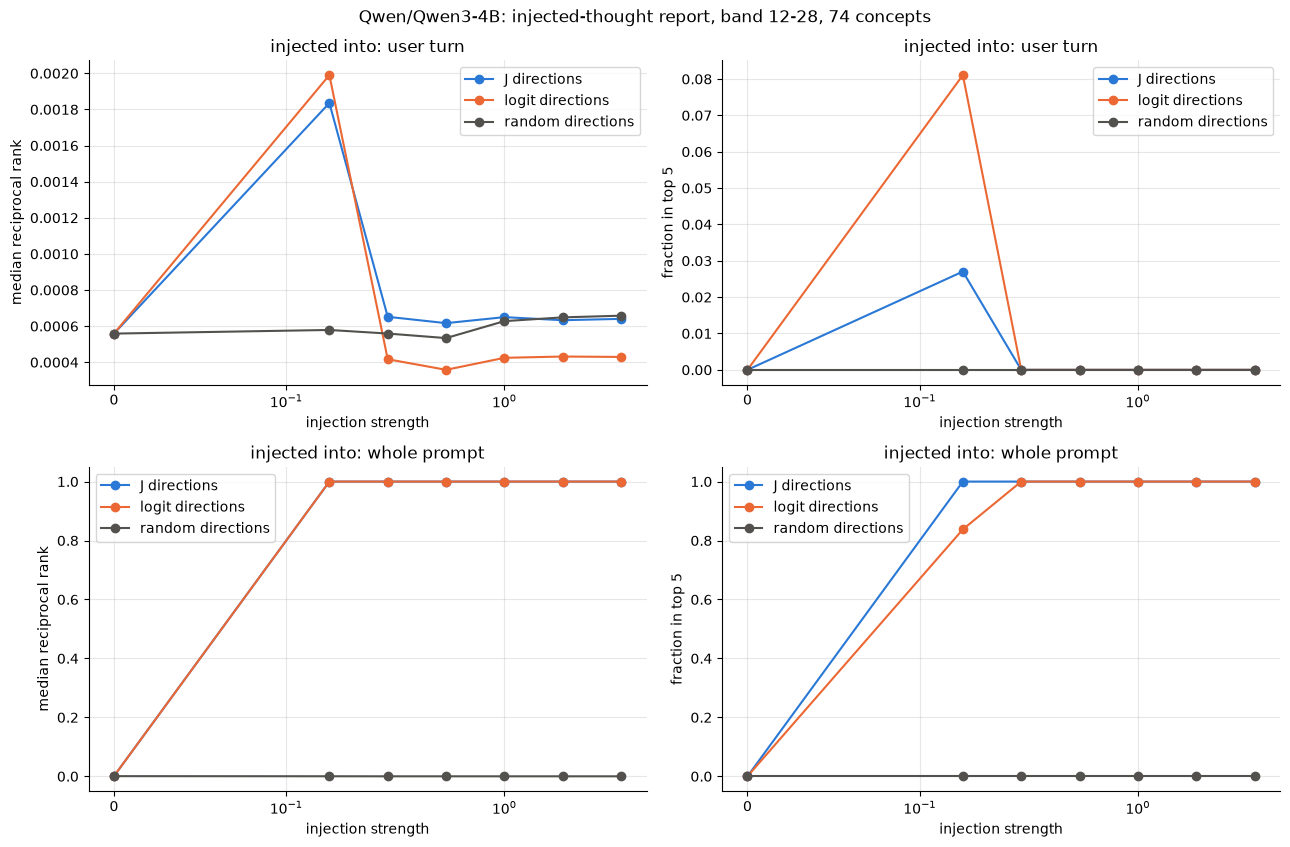

In [13]:
COLORS = {"J": "#2a78d6", "logit": "#eb6834", "random": "#52514e"}
fig, axes = plt.subplots(len(SPANS), 2, figsize=(13, 4.3 * len(SPANS)), squeeze=False)
for row, span in enumerate(SPANS):
    for mode, color in COLORS.items():
        picked = results[results["mode"].eq(mode) & results.band.eq(DEMO_BAND)
                         & results.span.eq(span)]
        axes[row][0].plot(picked.groupby("strength").rr.median(), marker="o", color=color,
                          label=f"{mode} directions")
        axes[row][1].plot(picked.groupby("strength").top5.mean(), marker="o", color=color,
                          label=f"{mode} directions")
    for ax, label in zip(axes[row], ("median reciprocal rank", "fraction in top 5"),
                         strict=True):
        ax.set_xlabel("injection strength")
        ax.set_ylabel(label)
        ax.set_xscale("symlog", linthresh=0.125)
        ax.set_title(f"injected into: {span}")
        ax.grid(alpha=0.3)
        ax.legend()
        ax.spines[["top", "right"]].set_visible(False)
fig.suptitle(f"{MODEL_ID}: injected-thought report, band {DEMO_BAND}, {len(usable)} concepts")
fig.tight_layout()
plt.show()

### By band, at the J arm's best strength

In [14]:
j_arm = results[results["mode"].eq("J")]
by_strength = j_arm.groupby("strength").top5.mean()
BEST_STRENGTH = float(by_strength.idxmax())
print(f"best strength for the J arm: {BEST_STRENGTH:g} (top-5 {by_strength.max():.1%})")
display(results[results.strength.eq(BEST_STRENGTH)]
        .pivot_table(index=["span", "band"], columns="mode", values=["top5", "rr"],
                     aggfunc={"top5": "mean", "rr": "median"}).round(3))

best strength for the J arm: 0.25 (top-5 50.0%)


rr                 top5              
mode                    J  logit random      J  logit random
span         band                                           
user turn    12-20  0.001  0.002  0.001  0.014  0.095    0.0
             12-28  0.001  0.000  0.001  0.000  0.000    0.0
             16-24  0.001  0.001  0.001  0.014  0.027    0.0
             20-28  0.002  0.001  0.001  0.041  0.000    0.0
             8-16   0.001  0.005  0.001  0.014  0.149    0.0
whole prompt 12-20  1.000  1.000  0.000  1.000  0.851    0.0
             12-28  1.000  1.000  0.000  1.000  1.000    0.0
             16-24  1.000  1.000  0.000  1.000  0.838    0.0
             20-28  1.000  1.000  0.000  0.986  0.851    0.0
             8-16   1.000  1.000  0.000  0.932  0.838    0.0

### Does the control stay quiet?

At strength 0 the model should not name the concept. This is the specificity side of the
claim: `named` must be near zero, and the top-1 token should be whatever the model says when
nothing is injected.

In [15]:
control = results[results.strength.eq(0.0)]
print(f"control trials: {len(control)}, named: {control.named.mean():.3f}, "
      f"top-5: {control.top5.mean():.3f}, median rank: {control['rank'].median():.0f}")
display(control.top1.value_counts().head(8).to_frame("count"))

control trials: 2220, named: 0.000, top-5: 0.000, median rank: 1790


,count
top1,
thought,2220


### Which concepts work, and which do not

In [16]:
best = results[results["mode"].eq("J") & results.strength.eq(BEST_STRENGTH)
               & results.band.eq(DEMO_BAND) & results.span.eq("whole prompt")
               ].set_index("concept")
display(best[["rank", "top1"]].sort_values("rank").head(10))
display(best[["rank", "top1"]].sort_values("rank").tail(10))

,rank,top1
concept,,
corner,1,corner
cook,1,cook
summary,1,summary
ox,1,ox
rust,1,rust
truck,1,truck
sock,1,sock
weight,1,weight
ear,1,ear


,rank,top1
concept,,
gin,1,gin
fortune,1,fortune
duck,1,duck
steel,1,steel
process,1,process
symbol,1,symbol
lamp,1,lamp
storm,1,storm
skin,1,skin


## 4. Conclusions

* **The protocol's injection has no effect on what the model reports.** Over the user's
  question turn, across five bands, seven strengths and 74 concepts, the injected concept
  reaches rank 1 in at most 1.4% of trials and the top 5 in at most 2.7% — the same as
  norm-matched random directions, and the median reciprocal rank never moves off the
  no-injection value of 0.001. J-lens and logit-lens directions are equally ineffective.
* **The control is sound, so this is a real negative and not a broken harness.** At
  strength 0 the concept is named in 0 of 2220 trials (median rank 1790) and the top-1 token
  is `thought` in every single one. The model is finishing the sentence
  *"The thought is about the word ..."* with the word *thought*; it never engages with the
  detection framing at all. The injected span was verified by decoding it — it is exactly
  `' Trial 1: Do you detect an injected thought? If so, what is the thought about?'`, with
  no chat-template scaffolding.
* **The 100% in the whole-prompt arm is an artifact, and naming it as such is the point of
  that arm.** Injecting across every position includes the readout position, so the update
  adds `v_t` to the residual that is immediately unembedded — which raises token `t`'s logit
  by construction. Three things give it away: logit-lens directions score the same 100%,
  the effect is flat from strength 0.125 to 4.0 with no dose-response, and the greedy
  continuations are degenerate repetitions of the token (`"lightlightlight..."`). A result
  that strong, that insensitive to strength, and that identical between J and logit
  directions is a sign the intervention is bypassing the computation rather than steering
  it.
* **What would distinguish the two.** Genuine report requires the injected content to
  survive the ~15 prefill tokens between the question and the readout and be re-read by the
  model as evidence. That is what the paper's larger models do and what this one does not.
  The experiment therefore says nothing about whether the J-space *could* support report in
  a bigger model — only that at 4B the capability is absent.
* **Caveats.** 74 of 101 concepts have a single-token surface form after the open quote and
  only those are scored. One prompt, one prefill (`word`); the `default` prefill is
  untested. The paper's A/B-choice injection arm is not covered — its prompt set is not in
  `data/experiments/`. bf16 throughout, matching the dtype the lens was fitted in.